# 📈 Linear Regression – Learn by Doing

### Today you will:
- Understand what regression is
- Predict real-world values using Python


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [ ]:
# Creating a simple dataset
# Study Hours vs Exam Score

data = {
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8],
    "Exam_Score":   [35, 40, 50, 55, 65, 70, 78, 85]
}

df = pd.DataFrame(data)
df


,Hours_Studied,Exam_Score
0,1,35
1,2,40
2,3,50
3,4,55
4,5,65
5,6,70
6,7,78
7,8,85


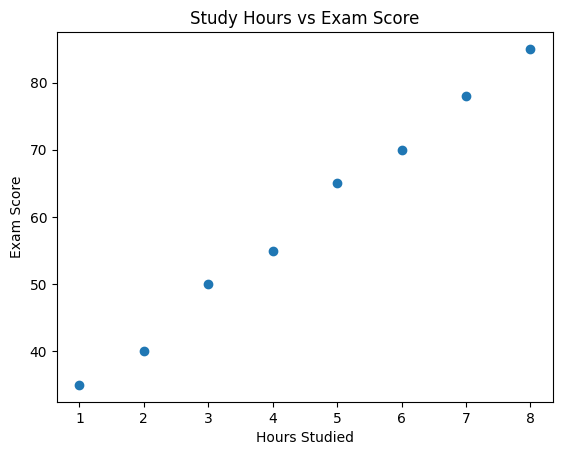

In [ ]:
# Visualizing the data
plt.scatter(df["Hours_Studied"], df["Exam_Score"])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")
plt.show()

In [ ]:
# Input (X) and Output (y)
X = df[["Hours_Studied"]]   # input must be 2D
y = df["Exam_Score"]        # output

In [ ]:
# Create and train the model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
m = model.coef_[0]
c = model.intercept_

print(f"m = {m:.2f}")
print(f"c = {c:.2f}")

m = 7.26
c = 27.07


In [ ]:
# Predict exam score for a new student
hours = 9
new_data = pd.DataFrame({"Hours_Studied": [hours]})
predicted_score = model.predict(new_data)

print(f"If a student studies {hours} hours, predicted score is {predicted_score[0]:.2f}")

If a student studies 9 hours, predicted score is 92.43


In [ ]:
# Model evaluation
predictions = model.predict(X)
error = mean_absolute_error(y, predictions)

print("Mean Absolute Error:", error)

Mean Absolute Error: 0.8809523809523823


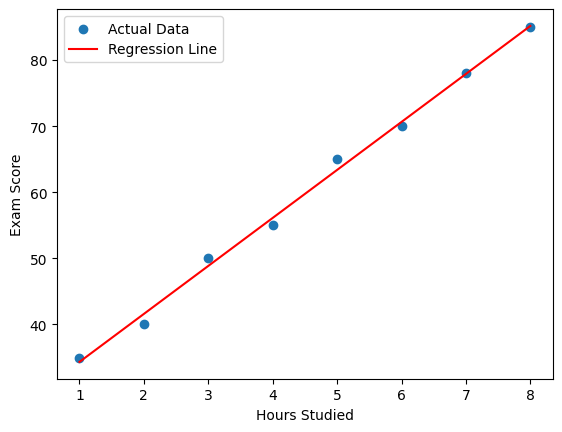

In [ ]:
plt.scatter(X, y, label="Actual Data")

plt.plot(X, model.predict(X), color="red", label="Regression Line")

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.legend()
plt.show()

## 🧠 Mini Activity

Try this:
1. Change the dataset values
2. Add a new data point
3. Retrain the model
4. Observe how predictions change

💡 This is how real ML experimentation works.

In [ ]:
# Experience vs Salary dataset

data2 = {
    "Years_Experience": [0, 1, 2, 3, 4, 5],
    "Salary_LPA":       [3, 4, 5.5, 7, 8.5, 10]
}

df2 = pd.DataFrame(data2)

X2 = df2[["Years_Experience"]]
y2 = df2["Salary_LPA"]

model2 = LinearRegression()
model2.fit(X2, y2)
years = 9

new_data = pd.DataFrame({"Years_Experience": [years]})

predicted_salary = model2.predict(new_data)
print(f"If an emplyee has {years} years of experience, predicted salary is {predicted_salary[0]:.2f}")

If an emplyee has 3.5 years of experience, predicted salary is 7.76


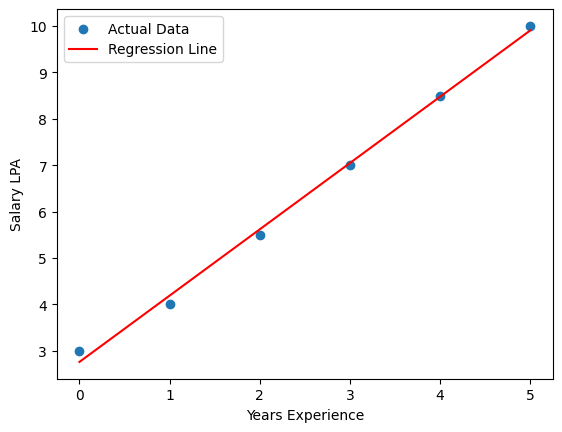

In [ ]:
plt.scatter(X2, y2, label="Actual Data")

plt.plot(X2, model2.predict(X2), color="red", label="Regression Line")

plt.xlabel("Years Experience")
plt.ylabel("Salary LPA")

plt.legend()
plt.show()

---
## 🏡 Real-World Project: California House Price Prediction

Now let's use a real dataset! We will use the **California Housing Dataset**.
Our goal is to see if we can predict the value of a house based on the **Median Income** of the neighborhood.

*Note: In this dataset, Income is measured in tens of thousands (e.g., 5 = \$50,000) and House Value is measured in hundreds of thousands (e.g., 2 = \$200,000).*

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# 1. Load the real-world dataset
california = fetch_california_housing(as_frame=True)
df_housing = california.frame

# 2. To make our plot easy to read, let's take a random sample of 500 houses
df_sample = df_housing.sample(n=500, random_state=42)

# 3. Define our Features (X) and Target (y)
X_house = df_sample[['MedInc']]       # Median Income
y_house = df_sample['MedHouseVal']    # Median House Value

# Let's see the first 5 rows!
display(df_sample[['MedInc', 'MedHouseVal']].head())

,MedInc,MedHouseVal
20046,1.6812,0.47700
3024,2.5313,0.45800
15663,3.4801,5.00001
20484,5.7376,2.18600
9814,3.7250,2.78000


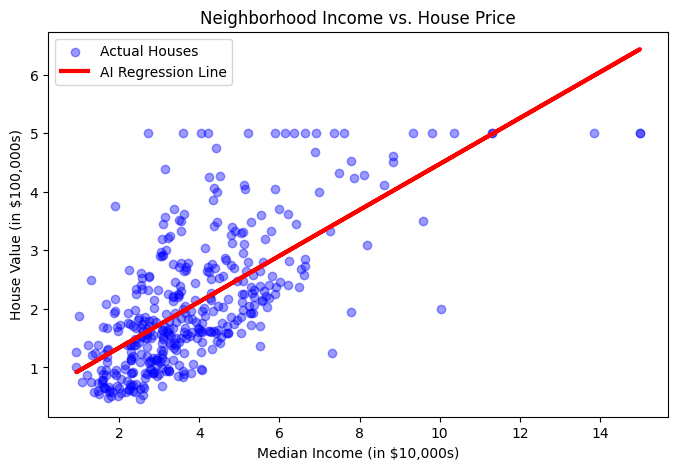

In [ ]:
# 1. Split the data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

# 2. Create and train the model
house_model = LinearRegression()
house_model.fit(X_train, y_train)

# 3. Visualize the Real Data vs Our Model's Line
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', alpha=0.4, label="Actual Houses")
plt.plot(X_train, house_model.predict(X_train), color='red', linewidth=3, label="AI Regression Line")

plt.title("Neighborhood Income vs. House Price")
plt.xlabel("Median Income (in $10,000s)")
plt.ylabel("House Value (in $100,000s)")
plt.legend()
plt.show()

In [ ]:
# Evaluate the model on the Test Set
test_predictions = house_model.predict(X_test)
error = mean_absolute_error(y_test, test_predictions)
print(f"Model Error: On average, our predictions are off by ${error * 100000:,.0f}")

# Predict a brand new neighborhood
new_income = 5.0  # representing $50,000
new_data = pd.DataFrame({"MedInc": [new_income]})

predicted_price = house_model.predict(new_data)[0]

print(f"\n🔮 If a neighborhood's median income is ${new_income * 10000:,.0f},")
print(f"the AI predicts the house will cost: ${predicted_price * 100000:,.0f}")

Model Error: On average, our predictions are off by $63,927

🔮 If a neighborhood's median income is $50,000,
the AI predicts the house will cost: $251,345
